In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = r"C:\Users\ROHITH KANNA S\WiFiVision"

pred = np.load(
    os.path.join(
        BASE_DIR,
        "data",
        "processed",
        "baseline_split",
        "baseline_predictions.npy"
    )
)

target = np.load(
    os.path.join(
        BASE_DIR,
        "data",
        "processed",
        "baseline_split",
        "baseline_targets.npy"
    )
)

errors = np.load(
    os.path.join(
        BASE_DIR,
        "data",
        "processed",
        "baseline_split",
        "baseline_joint_errors.npy"
    )
)

print("Predictions:", pred.shape)
print("Targets    :", target.shape)
print("Errors     :", errors.shape)

Predictions: (972, 17, 2)
Targets    : (972, 17, 2)
Errors     : (972, 17)


In [2]:
# MM-Fi 17-joint skeleton connections

SKELETON = [
    (0, 1),    # head/neck
    (1, 2),    # neck -> left shoulder
    (2, 3),    # left shoulder -> left elbow
    (3, 4),    # left elbow -> left wrist

    (1, 5),    # neck -> right shoulder
    (5, 6),    # right shoulder -> right elbow
    (6, 7),    # right elbow -> right wrist

    (1, 8),    # neck -> torso
    (8, 9),    # torso -> left hip
    (9, 10),   # left hip -> left knee
    (10, 11),  # left knee -> left ankle

    (8, 12),   # torso -> right hip
    (12, 13),  # right hip -> right knee
    (13, 14),  # right knee -> right ankle

    (8, 15),   # torso -> left side
    (8, 16),   # torso -> right side
]

print("Number of joints:", 17)
print("Number of skeleton connections:", len(SKELETON))

Number of joints: 17
Number of skeleton connections: 16


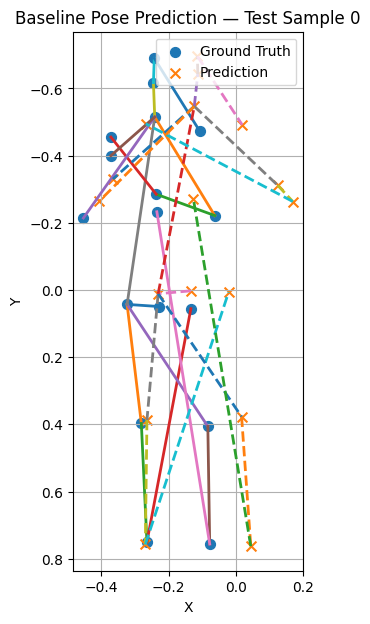

In [3]:
# Plot one test sample:
# Ground truth vs model prediction

sample = 0

gt = target[sample]
pr = pred[sample]

fig, ax = plt.subplots(figsize=(7, 7))

# Ground-truth skeleton
for a, b in SKELETON:
    ax.plot(
        [gt[a, 0], gt[b, 0]],
        [gt[a, 1], gt[b, 1]],
        linewidth=2
    )

ax.scatter(
    gt[:, 0],
    gt[:, 1],
    s=50,
    label="Ground Truth"
)

# Predicted skeleton
for a, b in SKELETON:
    ax.plot(
        [pr[a, 0], pr[b, 0]],
        [pr[a, 1], pr[b, 1]],
        linestyle="--",
        linewidth=2
    )

ax.scatter(
    pr[:, 0],
    pr[:, 1],
    s=50,
    marker="x",
    label="Prediction"
)

ax.set_title(f"Baseline Pose Prediction — Test Sample {sample}")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.invert_yaxis()
ax.set_aspect("equal")
ax.legend()
ax.grid(True)

plt.show()

In [4]:
# Inspect the 17 joint coordinates with their indices

sample = 0

gt = target[sample]

print("Joint coordinates for test sample 0")
print("=" * 45)

for i, (x, y) in enumerate(gt):
    print(f"Joint {i:02d}: X = {x: .4f}, Y = {y: .4f}")

Joint coordinates for test sample 0
Joint 00: X = -0.2285, Y =  0.0492
Joint 01: X = -0.3235, Y =  0.0428
Joint 02: X = -0.2811, Y =  0.3973
Joint 03: X = -0.2644, Y =  0.7506
Joint 04: X = -0.1336, Y =  0.0556
Joint 05: X = -0.0831, Y =  0.4061
Joint 06: X = -0.0775, Y =  0.7563
Joint 07: X = -0.2349, Y = -0.2329
Joint 08: X = -0.2412, Y = -0.5151
Joint 09: X = -0.2451, Y = -0.6174
Joint 10: X = -0.2425, Y = -0.6899
Joint 11: X = -0.1069, Y = -0.4725
Joint 12: X = -0.0625, Y = -0.2216
Joint 13: X = -0.2370, Y = -0.2853
Joint 14: X = -0.3716, Y = -0.4552
Joint 15: X = -0.4536, Y = -0.2143
Joint 16: X = -0.3719, Y = -0.3998


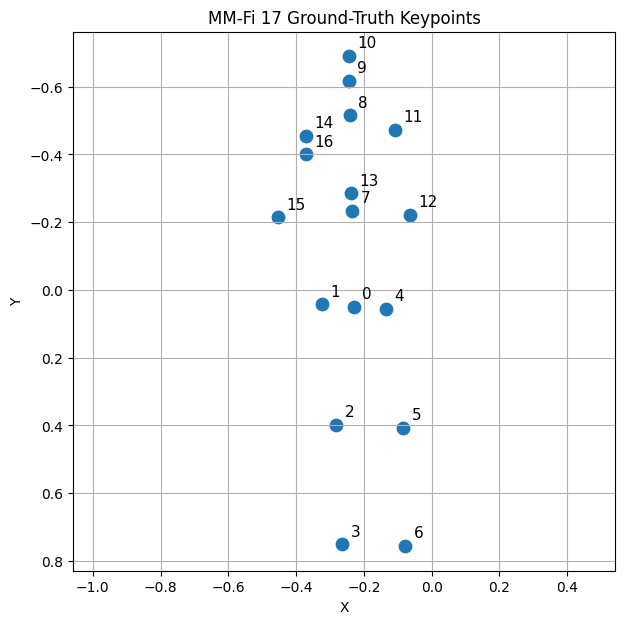

In [5]:
# Plot the 17 joints with their indices

sample = 0
gt = target[sample]

plt.figure(figsize=(7, 7))

plt.scatter(
    gt[:, 0],
    gt[:, 1],
    s=80
)

for i, (x, y) in enumerate(gt):
    plt.annotate(
        str(i),
        (x, y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=11
    )

plt.title("MM-Fi 17 Ground-Truth Keypoints")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().invert_yaxis()
plt.axis("equal")
plt.grid(True)

plt.show()

In [6]:
# ============================================================
# COCO / MM-Fi 17-JOINT SKELETON
# ============================================================

SKELETON = [
    (0, 1),   # nose -> left eye
    (0, 2),   # nose -> right eye
    (1, 3),   # left eye -> left ear
    (2, 4),   # right eye -> right ear

    (0, 5),   # nose -> left shoulder
    (0, 6),   # nose -> right shoulder

    (5, 6),   # shoulders

    (5, 7),   # left shoulder -> left elbow
    (7, 9),   # left elbow -> left wrist

    (6, 8),   # right shoulder -> right elbow
    (8, 10),  # right elbow -> right wrist

    (5, 11),  # left shoulder -> left hip
    (6, 12),  # right shoulder -> right hip

    (11, 12), # hips

    (11, 13), # left hip -> left knee
    (13, 15), # left knee -> left ankle

    (12, 14), # right hip -> right knee
    (14, 16), # right knee -> right ankle
]

JOINT_NAMES = [
    "Nose",
    "Left Eye",
    "Right Eye",
    "Left Ear",
    "Right Ear",
    "Left Shoulder",
    "Right Shoulder",
    "Left Elbow",
    "Right Elbow",
    "Left Wrist",
    "Right Wrist",
    "Left Hip",
    "Right Hip",
    "Left Knee",
    "Right Knee",
    "Left Ankle",
    "Right Ankle",
]

print("Joints:", len(JOINT_NAMES))
print("Connections:", len(SKELETON))

Joints: 17
Connections: 18


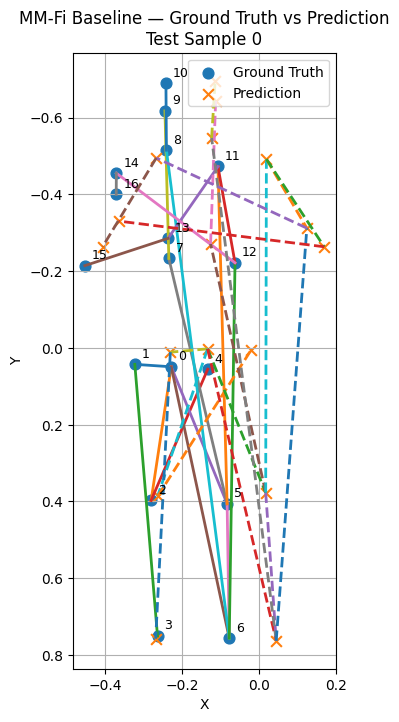

In [7]:
# ============================================================
# GROUND TRUTH vs PREDICTION
# ============================================================

sample = 0

gt = target[sample]
pr = pred[sample]

fig, ax = plt.subplots(figsize=(7, 8))

# Ground truth
for a, b in SKELETON:
    ax.plot(
        [gt[a, 0], gt[b, 0]],
        [gt[a, 1], gt[b, 1]],
        linewidth=2
    )

ax.scatter(
    gt[:, 0],
    gt[:, 1],
    s=60,
    label="Ground Truth"
)

# Prediction
for a, b in SKELETON:
    ax.plot(
        [pr[a, 0], pr[b, 0]],
        [pr[a, 1], pr[b, 1]],
        linestyle="--",
        linewidth=2
    )

ax.scatter(
    pr[:, 0],
    pr[:, 1],
    s=60,
    marker="x",
    label="Prediction"
)

# Joint numbers
for i in range(17):
    ax.annotate(
        str(i),
        (gt[i, 0], gt[i, 1]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title(
    f"MM-Fi Baseline — Ground Truth vs Prediction\n"
    f"Test Sample {sample}"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.invert_yaxis()
ax.set_aspect("equal")
ax.grid(True)
ax.legend()

plt.show()

In [8]:
# ============================================================
# PER-JOINT ERROR ANALYSIS
# ============================================================

mean_joint_error = errors.mean(axis=0)
median_joint_error = np.median(errors, axis=0)

print("Per-joint test error")
print("=" * 50)

for i in range(17):
    print(
        f"{i:02d}  {JOINT_NAMES[i]:15s} "
        f"Mean: {mean_joint_error[i]:.4f}   "
        f"Median: {median_joint_error[i]:.4f}"
    )

print("\nWorst 5 joints:")

worst = np.argsort(mean_joint_error)[::-1][:5]

for i in worst:
    print(
        f"{i:02d}  {JOINT_NAMES[i]:15s} "
        f"{mean_joint_error[i]:.4f}"
    )

Per-joint test error
00  Nose            Mean: 0.0877   Median: 0.0644
01  Left Eye        Mean: 0.0892   Median: 0.0645
02  Right Eye       Mean: 0.0883   Median: 0.0589
03  Left Ear        Mean: 0.0791   Median: 0.0527
04  Right Ear       Mean: 0.0881   Median: 0.0649
05  Left Shoulder   Mean: 0.0945   Median: 0.0610
06  Right Shoulder  Mean: 0.0945   Median: 0.0665
07  Left Elbow      Mean: 0.0969   Median: 0.0703
08  Right Elbow     Mean: 0.1153   Median: 0.0848
09  Left Wrist      Mean: 0.1414   Median: 0.1148
10  Right Wrist     Mean: 0.1411   Median: 0.1154
11  Left Hip        Mean: 0.1106   Median: 0.0761
12  Right Hip       Mean: 0.1869   Median: 0.1469
13  Left Knee       Mean: 0.3432   Median: 0.3034
14  Right Knee      Mean: 0.1115   Median: 0.0787
15  Left Ankle      Mean: 0.1760   Median: 0.1409
16  Right Ankle     Mean: 0.3233   Median: 0.2878

Worst 5 joints:
13  Left Knee       0.3432
16  Right Ankle     0.3233
12  Right Hip       0.1869
15  Left Ankle      0.1760
09  

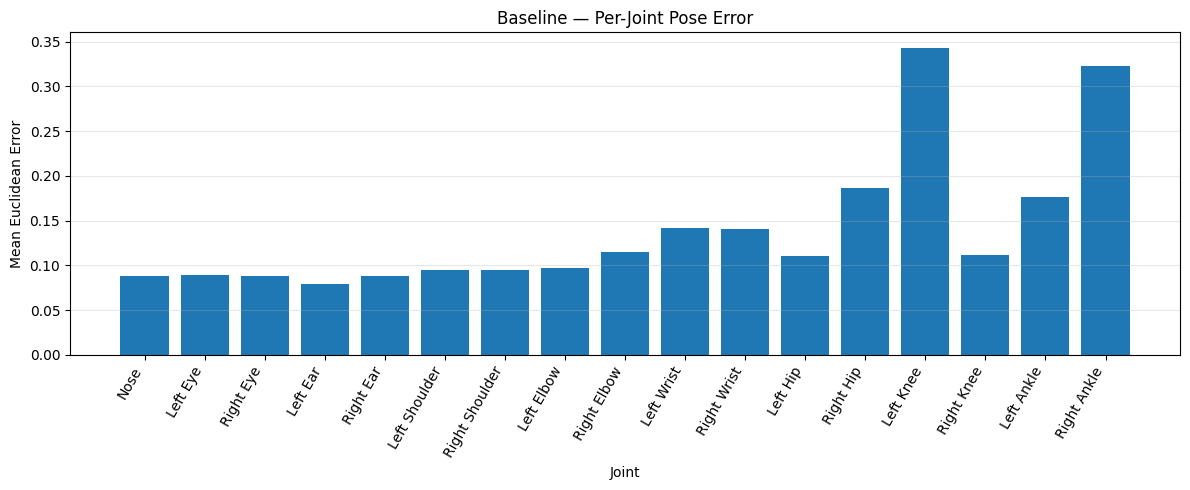

In [9]:
# ============================================================
# PER-JOINT ERROR PLOT
# ============================================================

plt.figure(figsize=(12, 5))

plt.bar(
    range(17),
    mean_joint_error
)

plt.xticks(
    range(17),
    JOINT_NAMES,
    rotation=60,
    ha="right"
)

plt.ylabel("Mean Euclidean Error")
plt.xlabel("Joint")
plt.title("Baseline — Per-Joint Pose Error")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# PER-JOINT PCK
# ============================================================

thresholds = [0.05, 0.10, 0.15, 0.20]

print("Per-joint PCK")
print("=" * 70)

for threshold in thresholds:

    pck_per_joint = np.mean(
        errors <= threshold,
        axis=0
    )

    print(f"\nPCK @ {threshold:.2f}")

    for i in range(17):
        print(
            f"{i:02d}  "
            f"{JOINT_NAMES[i]:15s} "
            f"{pck_per_joint[i] * 100:6.2f}%"
        )

Per-joint PCK

PCK @ 0.05
00  Nose             33.13%
01  Left Eye         30.66%
02  Right Eye        39.71%
03  Left Ear         46.60%
04  Right Ear        32.00%
05  Left Shoulder    33.33%
06  Right Shoulder   36.11%
07  Left Elbow       31.69%
08  Right Elbow      29.63%
09  Left Wrist       18.11%
10  Right Wrist      18.21%
11  Left Hip         30.04%
12  Right Hip        10.49%
13  Left Knee         0.51%
14  Right Knee       24.49%
15  Left Ankle       12.35%
16  Right Ankle       1.34%

PCK @ 0.10
00  Nose             78.60%
01  Left Eye         78.91%
02  Right Eye        77.16%
03  Left Ear         77.47%
04  Right Ear        77.78%
05  Left Shoulder    74.79%
06  Right Shoulder   71.81%
07  Left Elbow       68.31%
08  Right Elbow      57.10%
09  Left Wrist       42.49%
10  Right Wrist      43.52%
11  Left Hip         61.01%
12  Right Hip        30.97%
13  Left Knee         2.47%
14  Right Knee       61.83%
15  Left Ankle       34.16%
16  Right Ankle       5.66%

PCK @ 0.1

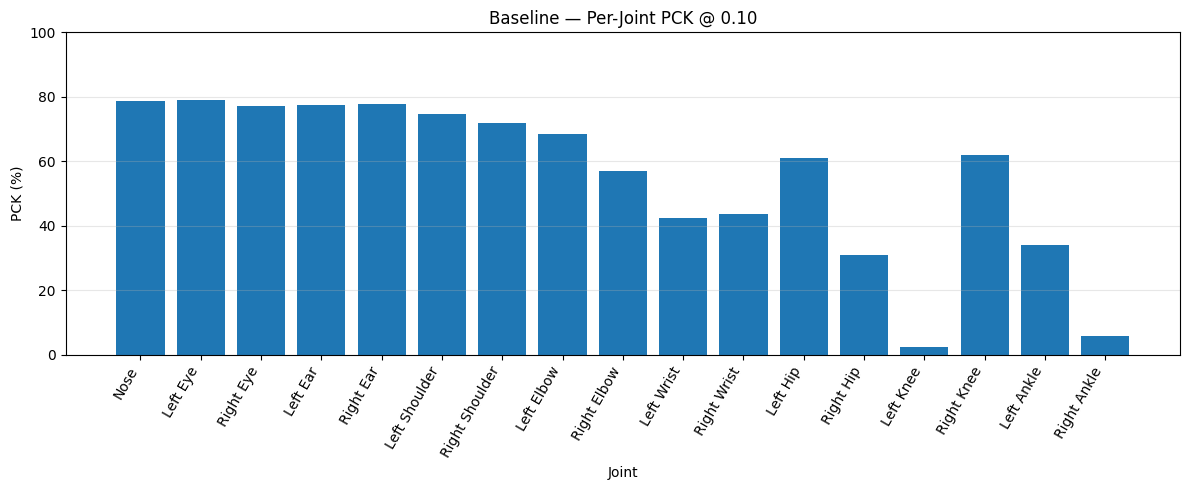

In [11]:
# ============================================================
# PCK @ 0.10 — JOINT-WISE VISUALIZATION
# ============================================================

threshold = 0.10

pck_joint = np.mean(
    errors <= threshold,
    axis=0
)

plt.figure(figsize=(12, 5))

plt.bar(
    range(17),
    pck_joint * 100
)

plt.xticks(
    range(17),
    JOINT_NAMES,
    rotation=60,
    ha="right"
)

plt.ylabel("PCK (%)")
plt.xlabel("Joint")
plt.title("Baseline — Per-Joint PCK @ 0.10")

plt.ylim(0, 100)
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()